# Librerías

In [1]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar

plt.rcParams["figure.figsize"] = (10,5) #tamaño de los gráficos: ancho x alto

# Método de Euler implícito

## Charlar la idea basándose en la teórica

### Para el ejercicio 5.



In [2]:
# para resolver la ec. no lineal del Euler implícito uso, por ejemplo
# Newton-Raphson con cant. fija de pasos
def paso_newtonRaphson(func, deriv_f, x):
    x_sig = x - func(x)/deriv_f(x)
    return x_sig

def metodo_newtonRaphson_cant(func, deriv_f, x_inic, cant_pasos):
    x = x_inic

    for i in range(0,cant_pasos,1):
        x_nuevo = paso_newtonRaphson(func, deriv_f, x)
        x = x_nuevo

    return x




def paso_euler_implicito(x, t, h, f, fx, cant_iter_newton):
  # defino la func y la derivada internas porque se las tengo que pasar a Newton-Raphson
  f_newton  = lambda y: y - x - h*f(t+h, y)
  deriv_f_newton = lambda y: 1 - h*fx(t+h, y)

  x_sig = metodo_newtonRaphson_cant(f_newton, deriv_f_newton, x, cant_iter_newton)

  return x_sig


def metodo_euler_implicito(x0, t0, h, f, fx, cant_pasos, cant_pasos_newton):
  x = x0
  t = t0

  valores_x = np.array([]) #vector vacío
  valores_x = np.append(valores_x, x0) #agrego elemento al final

  valores_t = np.array([])
  valores_t = np.append(valores_t, t0) #agrego elemento al final del vector

  for i in range(0,cant_pasos,1):

    x_sig = paso_euler_implicito(x, t, h, f, fx, cant_pasos_newton)
    valores_x = np.append(valores_x, x_sig)

    t_sig = t + h
    valores_t = np.append(valores_t, t_sig)

    t = t_sig
    x = x_sig

  return valores_t, valores_x

## Ejemplo Euler implícito

$$
\begin{cases}
x'(t)&=t\cos(x(t))\\
x(0)&=3
\end{cases}
$$

### Usar el método de Euler implícito para aproximar la solución del PVI con $t$ entre 0 y 2. Utilizar 5 pasos para Newton. Graficar los resultados obtenidos.

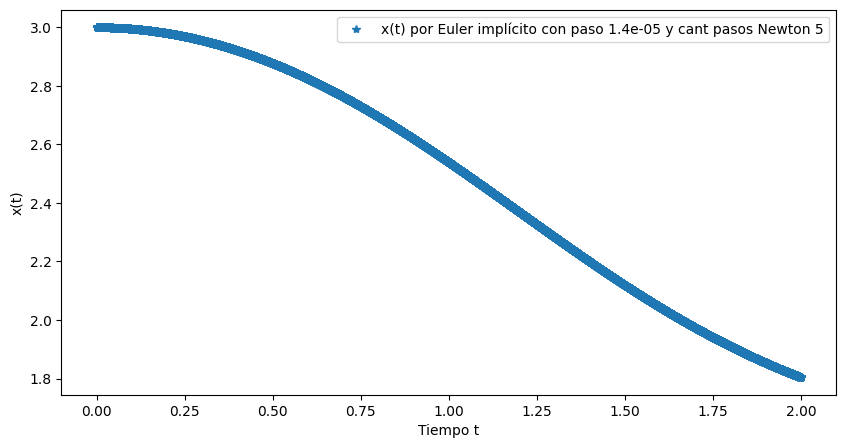

In [3]:
def func(t,x):
  y = t*np.cos(x)
  return y

def func_deriv_x(t,x): # necesito la deriv resp a x
  y = (-1)*t*np.sin(x)
  return y


x0 = 3
t0 = 0
tf = 2
h = 1.4*10**(-5)
# h = 10**(-6)
N = int((tf-t0)/h) #devuelve parte entera: detaller técnico para que N sea entero y el range no se queje.
N_newton = 5

vals_t, vals_x = metodo_euler_implicito(x0, t0, h, func, func_deriv_x, N, N_newton)
plt.plot(vals_t ,vals_x, '*', label='x(t) por Euler implícito con paso {} y cant pasos Newton 5'.format(h))
plt.xlabel('Tiempo t')
plt.ylabel('x(t)')
plt.legend()